## Intro

## Imports

In [1]:
# for data scraping
import requests
from bs4 import BeautifulSoup
# for numerical data analysis
import pandas as p
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# for language analysis
import spacy
# the spaCy package comes without a model, it must be loaded separately
# we focus on the german model (de) of small size (sm) trained on news data (news)
# we do this by commenting IN the following line on the first run of the notebook
# !python -m spacy download de_core_news_sm

In [2]:
# now we load the language model
nlp = spacy.load("de_core_news_sm")

## Data scraping

We are interested in data from website such as this one: https://www.rossmann.de/de/pflege-und-duft/duefte-und-parfum/damenduefte-und-damenparfum/c/olcat3_n_45?q=%3Arelevance%3A&page=2&pageSize=60

Note the website's structure and address may be subject to change, so the `request` below may require modifications in the future.

### Product listings page

The listings page containts product names, prices and the individual product pages (details pages).

In [7]:
# get the URL of interest by gender (men/women) and by page (for products spanning across multiple pages)
url_base = "https://www.rossmann.de"
url_products_list = "/de/pflege-und-duft/duefte-und-parfum/" # old: "/de/pflege-und-duft/duefte-und-parfum/c/olcat2_5?q=%3Arelevance%3Ageschlecht%3AATTR_Geschlecht.LOV_Geschlecht_15726"
url_women = "damenduefte-und-damenparfum/c/olcat3_n_45" # old: "7"
url_men =  "herrenduefte-und-herrenparfum/c/olcat3_n_46" # old: "6"
url_mid = "?q=%3Arelevance%3A&page="
url_end = "&pageSize=60" # valid values: 24, 36, 60
def url_join(gender, page):
    if gender == "men":
        url_gender = url_men
    elif gender == "women":
        url_gender = url_women
    else:
        print("Error: gender not properly specified")
    full_url = url_base + url_products_list + url_gender + url_mid + str(page) + url_end
    return full_url

In [8]:
# sample use
url_join("women", 1)

'https://www.rossmann.de/de/pflege-und-duft/duefte-und-parfum/damenduefte-und-damenparfum/c/olcat3_n_45?q=%3Arelevance%3A&page=1&pageSize=60'

In [9]:
# check whether a subsequent product page exists
def next_page(gender, page):
    response = requests.get(url_join(gender,page))
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    element_next_page = soup.find_all("li", class_="rm-pagination__sites-next")
    nolink_next_page = element_next_page[0].find("span", class_="rm-pagination__sites-nolink") # check whether a next-site pagination button with the class nolink exists, inidicating that there is NOT next page
    if nolink_next_page: # if the button nolink button DOES exist 
        return False
    else:
        return True

In [10]:
# retrieve a page
def soup_products_page(gender, page):
    response = requests.get(url_join(gender,page))
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    return soup.find_all("div", class_="rm-tile-product")
#
# extract prices (note we are interested in the per-liter price)
def get_price(product): # ignore "gift sets" that do not have per-liter prices
    price_tag = product.find("div", class_="rm-price__base") # we are interested in the price per liter, not per product
    price_full = price_tag.get_text(strip=True)
    price_string = "1 L = "
    if price_string in price_full:
        price_raw = price_full.split(" = ")[1].split(" €)")[0] # remove preceding + trailing characters
        price = price_raw.replace(".","").replace(",",".") # first remove four-digit separating dots, then replace decimal commas by dots
        return price
    else:
        return False
#
# extract further product data
def get_product_data(gender, page):
    names = []
    id1s = []
    id2s = []
    prices = []
    urls = []
    for product in soup_products_page(gender, page):
        price = get_price(product)
        if price:
            name = product.get("data-product-name")
            names.append(name)
            id1 = product.get("data-product-id")
            id1s.append(id1)
            id2 = product.get("data-product-id2")
            id2s.append(id2)
            url_end = product.find("a", class_="rm-tile-product__headline").get("href")
            url = url_base + url_end
            urls.append(url)
            prices.append(float(price))
        else:
            pass # ignore products without per-liter prices like gift sets
    df_gender_page = pd.DataFrame({
        "name": names,
        "id1": id1s,
        "id2": id2s,
        "price_per_L": prices,
        "gender": gender,
        "page": page,
        "url": urls
        })
    return df_gender_page
#
# batch extraction across pages
def all_pages(gender):
    page = 0
    list_df = []
    nextpage = True
    print(f"Beginning to scrape {gender}'s product pages.")
    while nextpage == True:
        print(f"Scraping page {page}.")
        list_df.append(get_product_data(gender, page))
        page += 1
        nextpage = next_page(gender, page)
    df_merged = pd.concat(list_df, ignore_index=True)
    print(f"Pages scraped: {page}. Products retrieved: {len(df_merged.index)}")
    return df_merged

In [ ]:
# batch extraction across genders
df_full = pd.concat([all_pages("women"), all_pages("men")], ignore_index=True)

Beginning to scrape women's product pages.
Scraping page 0.
Scraping page 1.
Scraping page 2.
Scraping page 3.
Scraping page 4.
Scraping page 5.
Scraping page 6.
Scraping page 7.
Pages scraped: 8. Products retrieved: 455
Beginning to scrape men's product pages.
Scraping page 0.
Scraping page 1.
Scraping page 2.
Scraping page 3.
Scraping page 4.
Pages scraped: 5. Products retrieved: 272


### Product details page

Using the individual product page URLs, we extract the description for each item from its product details page.

In [13]:
# request the page and extract the text description
def product_text(url):
    response = requests.get(url)
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    details = soup.find("div", id="GRP_PRODUKTDETAILS").find("div", class_="rm-cms")
    description = ""
    for detail in details:
        if detail.name == "h4" and detail.get_text(strip=True) == "Kontaktdaten":
            break
        elif detail.name == "p":
            description += detail.get_text(separator=' ', strip=True) + " "
    attribute = details.find("ul") # additional description, does not exist for all products. maybe used later
    return (description, attribute)

In [ ]:
# batch retrieval of the product descriptions
df_full["description"] = pd.NA
df_full["other_text"] = pd.NA
for i in df_full.index:
    len_women = len(df_full[df_full["gender"] == "women"])
    len_men = len(df_full[df_full["gender"] == "men"])
    url = df_full.at[i, "url"]
    text = product_text(url)
    df_full.at[i, "description"] = text[0]
    df_full.at[i, "other_text"] = text[1]
    if i < len_women:
        print(f"Progress: Women: {i+1:03}/{len_women}. Men: pending. Now reading: {text[0][:30]}..."+35*" ", end="\r")
    else:
        print(f"Progress: Women: done. Men: {i+1-len_women:03}/{len_men}. Now reading: {text[0][:30]}..."+35*" ", end="\r")

In [22]:
# inspect the data
df_full

,name,id1,id2,price_per_L,gender,page,url,description,other_text
0,"Fuel for Life Femme, EdP 50 ml",124563,3605520385568,1299.80,women,0,https://www.rossmann.de/de/pflege-und-duft-die...,Fuel For Life Femme von Diesel ist die Weitere...,<ul><li><b>Zielgruppe: </b>für Sie</li><li><b>...
1,"Eau de Iceberg Woman, EdT 100 ml",137257,8057714450098,249.90,women,0,https://www.rossmann.de/de/pflege-und-duft-ice...,Bereits seit 1974 eine stilvolle Sportswear-Co...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
2,"Cara Mia Ti Amo, EdP 50 ml",94058,4013670000245,299.80,women,0,https://www.rossmann.de/de/pflege-und-duft-eti...,"Ein frischer, blumiger Duft mit einem knackig-...",<ul><li><b>Zielgruppe:</b> für Sie</li><li><b>...
3,"Be Delicious Orchard Street, EdP 30ml",147067,85715950437,816.33,women,0,https://www.rossmann.de/de/pflege-und-duft-dkn...,Erlebe mit Be Delicious Orchard St. die Energi...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
4,"Be Delicious, EdP 30 ml",938037,763511009800,816.33,women,0,https://www.rossmann.de/de/pflege-und-duft-dkn...,DKNY Be Delicious ist ein energiegeladenes Eau...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
...,...,...,...,...,...,...,...,...,...
729,"Black Label Men, EdT 30 ml",37728,4011700888184,433.00,men,4,https://www.rossmann.de/de/pflege-und-duft-sol...,Schwarz und Weiß: konträr und doch konform. Pu...,<ul><li><b>Zielgruppe:</b> für Ihn</li><li><b>...
730,"Bottled, EdP 50 ml",103122,3614229828559,999.80,men,4,https://www.rossmann.de/de/pflege-und-duft-hug...,Seit 2020 gibt es den allseits beliebten Herre...,NaN
731,"Limited Edition Man, EdT 30 ml",132966,3616304072581,466.33,men,4,https://www.rossmann.de/de/pflege-und-duft-bru...,bruno banani Man Limited Edition 2023 Eau de T...,<ul><li><b>Zielgruppe: </b>für Ihn</li><li><b>...
732,"Boss Orange Man, EdT 40 ml",440981,737052348018,799.75,men,4,https://www.rossmann.de/de/pflege-und-duft-hug...,"Ein leicht würziger Duft für Männer, die gerne...",<ul><li>Kopfnote: roter Apfel</li><li>Herznote...


In [8]:
# store the data
df_full.to_csv("data/webshop_data_scraped_DE.csv", index=False)

## Numerical data analysis

### load & explore

In [3]:
# load the data
df = pd.read_csv("data/webshop_data_scraped_DE.csv")

In [4]:
df.head()

,name,id1,id2,price_per_L,gender,page,url,description,other_text
0,"Fuel for Life Femme, EdP 50 ml",124563,3605520385568,1299.80,women,0,https://www.rossmann.de/de/pflege-und-duft-die...,Fuel For Life Femme von Diesel ist die Weitere...,<ul><li><b>Zielgruppe: </b>für Sie</li><li><b>...
1,"Eau de Iceberg Woman, EdT 100 ml",137257,8057714450098,249.90,women,0,https://www.rossmann.de/de/pflege-und-duft-ice...,Bereits seit 1974 eine stilvolle Sportswear-Co...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
2,"Cara Mia Ti Amo, EdP 50 ml",94058,4013670000245,299.80,women,0,https://www.rossmann.de/de/pflege-und-duft-eti...,"Ein frischer, blumiger Duft mit einem knackig-...",<ul><li><b>Zielgruppe:</b> für Sie</li><li><b>...
3,"Be Delicious Orchard Street, EdP 30ml",147067,85715950437,816.33,women,0,https://www.rossmann.de/de/pflege-und-duft-dkn...,Erlebe mit Be Delicious Orchard St. die Energi...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
4,"Be Delicious, EdP 30 ml",938037,763511009800,816.33,women,0,https://www.rossmann.de/de/pflege-und-duft-dkn...,DKNY Be Delicious ist ein energiegeladenes Eau...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...


### gender-based price variations

How does the distribution of prices vary by gender? (Note: prices are in € per liter)

In [5]:
df.groupby("gender").price_per_L.describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
men,278.0,449.788237,288.670615,17.48,239.80,399.90,572.645,1499.67
women,456.0,497.027873,367.812944,9.50,229.01,444.65,733.000,2666.00


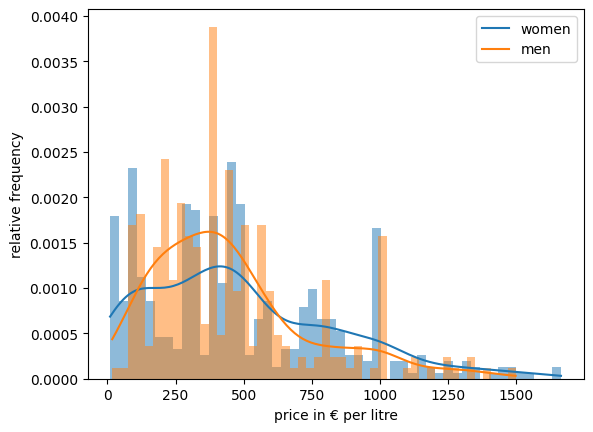

In [6]:
# visualisation
fig, ax = plt.subplots()
bins = 50
max_price = 1700
#
sns.histplot(ax = ax,
             data = df[(df.gender == "women") & (df.price_per_L <= max_price)],
             x = "price_per_L",
             bins = bins,
             stat = "density", #density=True,
             kde = True,
             edgecolor='none')
#
sns.histplot(ax = ax,
             data = df[(df.gender == "men") & (df.price_per_L <= max_price)],
             x = "price_per_L",
             bins = bins,
             stat = "density", #density=True,
             kde = True,
             edgecolor='none',
             alpha=0.5)
#
ax.set_xlabel("price in € per litre")
ax.set_ylabel("relative frequency")
ax.legend(["women", "men"])
#
plt.savefig("plots/DE/prices_pdf.png")
plt.show()

We observe that women's perfumes are higher on average, but not to a significant extent.

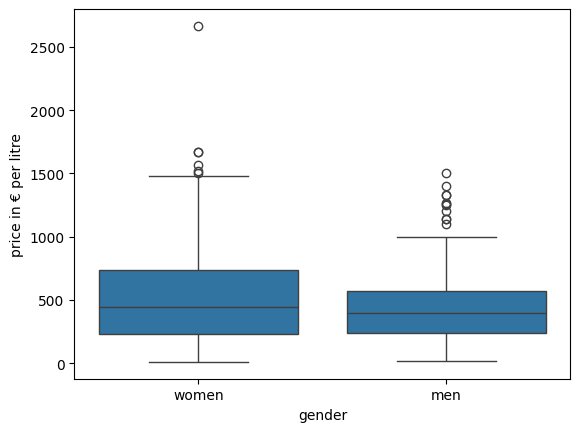

In [7]:
max_price = float('inf') # or 1700 to ignore extreme outlier
sns.boxplot(data = df[(df.price_per_L <= max_price)],
            y = "price_per_L",
            x = "gender");
plt.ylabel("price in € per litre")
plt.savefig("plots/DE/prices_box.png")
plt.show()

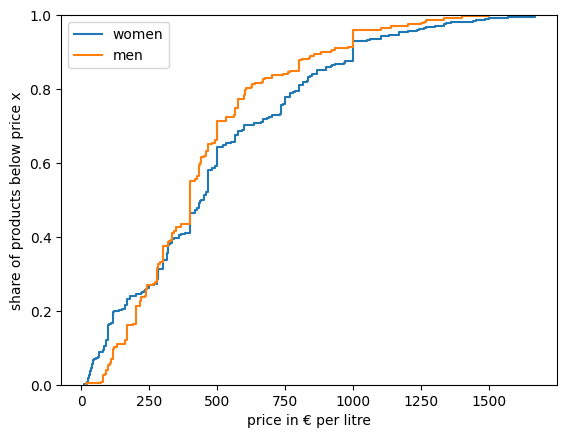

In [8]:
# compare the CDFs (cumulative density functions)
fig, ax = plt.subplots()
max_price = 1700
#
sns.ecdfplot(ax = ax,
             data = df[(df.gender == "women") & (df.price_per_L <= max_price)],
             x = "price_per_L")
#
sns.ecdfplot(ax = ax,
             data = df[(df.gender == "men") & (df.price_per_L <= max_price)],
             x = "price_per_L")
#
ax.set_xlabel("price in € per litre")
ax.set_ylabel("share of products below price x")
ax.legend(["women", "men"])
#
plt.savefig("plots/DE/prices_cdf.png")
plt.show()

We have not observed statistically significant differences between men's and women's 	fragrances when looking at the numerical (price) data. Next, we turn to the text data: descriptions of the fragrances on their product details page.

## Textual data analysis / NLP

### data preparation

In [9]:
# load the data
df = pd.read_csv("data/webshop_data_scraped_DE.csv")

In [10]:
# explore the data
df.head()

,name,id1,id2,price_per_L,gender,page,url,description,other_text
0,"Fuel for Life Femme, EdP 50 ml",124563,3605520385568,1299.80,women,0,https://www.rossmann.de/de/pflege-und-duft-die...,Fuel For Life Femme von Diesel ist die Weitere...,<ul><li><b>Zielgruppe: </b>für Sie</li><li><b>...
1,"Eau de Iceberg Woman, EdT 100 ml",137257,8057714450098,249.90,women,0,https://www.rossmann.de/de/pflege-und-duft-ice...,Bereits seit 1974 eine stilvolle Sportswear-Co...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
2,"Cara Mia Ti Amo, EdP 50 ml",94058,4013670000245,299.80,women,0,https://www.rossmann.de/de/pflege-und-duft-eti...,"Ein frischer, blumiger Duft mit einem knackig-...",<ul><li><b>Zielgruppe:</b> für Sie</li><li><b>...
3,"Be Delicious Orchard Street, EdP 30ml",147067,85715950437,816.33,women,0,https://www.rossmann.de/de/pflege-und-duft-dkn...,Erlebe mit Be Delicious Orchard St. die Energi...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...
4,"Be Delicious, EdP 30 ml",938037,763511009800,816.33,women,0,https://www.rossmann.de/de/pflege-und-duft-dkn...,DKNY Be Delicious ist ein energiegeladenes Eau...,<ul><li><b>Zielgruppe</b>: für Sie</li><li><b>...


We are interested in the "description" data - particularly how the wording varies between women's and men's fragrances. We will extract all (unique) descriptions per gender.

In [11]:
# note some text descriptions actually are floats, which spaCy cannot handle. We need to clean the data first.
df.description.apply(type).value_counts()

description
<class 'str'>      682
<class 'float'>     52
Name: count, dtype: int64

In [12]:
# for each gender, clean the data and gather the text descriptions
genders = ["women", "men"] # the website we look at works with a two-category gender dichotomy
# store them in a dictionary
dict_descriptions = {}
for gender in genders:
    descriptions = (df
                    [df.description.apply(lambda x: isinstance(x, str))] # keep only those with text description
                    .query("gender == @gender") # specify gender
                    .description # ignore all other columns
                    .drop_duplicates() # remove duplicate descriptions
                    .reset_index(drop=True)
    )
    dict_descriptions[gender] = descriptions

In [13]:
# explore the dictionary
dict_descriptions

{'women': 0      Fuel For Life Femme von Diesel ist die Weitere...
 1      Bereits seit 1974 eine stilvolle Sportswear-Co...
 2      Ein frischer, blumiger Duft mit einem knackig-...
 3      Erlebe mit Be Delicious Orchard St. die Energi...
 4      DKNY Be Delicious ist ein energiegeladenes Eau...
                              ...                        
 384    Die Kopfnote vermittelt Noten von Mandarine un...
 385    Spüre den echten Reichtum… Der Duft CASH WOMAN...
 386    Der köstliche blumig-fruchtige Duft öffnet sic...
 387    Das orientalisch-würzige Eau de Parfum Obsessi...
 388    Ein feminin-florientaler Duft für den selbstbe...
 Name: description, Length: 389, dtype: str,
 'men': 0      Die Automobilmarke Jaguar wurde 1922 gegründet...
 1      Die Automobilmarke Jaguar wurde 1922 gegründet...
 2      Rammstein startet das Jahr 2021 mit einer stre...
 3      WAIDMANNS HEIL INTENSE ist die perfekte Ergänz...
 4      Einzigartig, modern und fesselnd: KARL LAGERFE...
           

### lemmatization

To identify word frequencies, we have to lemmatise, i.e. grouping together different inflections of a word. Furthermore, we will ignore stop words.

In [14]:
dict_lemmata = {}
for gender in genders:
    list_lemmata = []
    docs = nlp.pipe(dict_descriptions[gender]) # attention: this returns a generator, so we have to either store its output to a list or (as we will do) use it directly
    for doc in docs: # iterate over the descriptions per gender
        lemmata = [token.lemma_ for token in doc if not (token.is_stop or token.is_punct)]
        # iterate over words/tokens per description. ignore stop words (und/oder/aber, der/die/das, sein/haben/...) and punctuation (,/./-)
        list_lemmata.extend(lemmata)
    dict_lemmata[gender] = list_lemmata

In [15]:
# compare below the move from text description to lemmatization
# note there seem to be some weird Lemmatizations e.g. with "Automarke"
print(dict_descriptions["men"][0])
print(dict_lemmata["men"][0:10])

Die Automobilmarke Jaguar wurde 1922 gegründet und zeichnet sich durch klassische, englische Eleganz und sportliche Luxus-Fahrzeuge aus. Als Vorreiter in Sachen Design und Technologie steht Jaguar für Stil, Performance und Modernität. Jaguar Parfüms greifen die DNA der ikonischen Automarke auf und bieten ein breites Portfolio an männlichen und modernen Düften für erfolgreiche, selbstbewusste Männer. Jaguar Classic Black ist ein verführerischer und charismatischer Herrenduft für den anspruchsvollen Mann. Zeitlose Eleganz und Dynamik werden in einer aufregenden Duftkomposition aus frischer Mandarine, würzigem Kardamom und warmem Zedernholz vereint. Der Duft erzeugt eine fesselnde Atmosphäre und verkörpert resolute Männlichkeit. 
['automobilmark', 'Jaguar', '1922', 'gründen', 'zeichnen', 'klassisch', 'englisch', 'Eleganz', 'sportlich', 'Luxus-Fahrzeug']


In [16]:
# create dataframe with the lemmata (dfl) per gender
dfl_men = pd.DataFrame(dict_lemmata["men"])
dfl_men.columns = ["lemma"]
dfl_men.lemma.value_counts().head(15)

lemma
Duft          289
Eau           108
de            107
Mann          104
Note          103
Toilette       89
frisch         73
würzig         59
verleihen      52
aromatisch     49
Kopfnote       48
Bergamotte     48
maskulin       48
warm           47
holzig         47
Name: count, dtype: int64

In [17]:
# create dataframe with the lemmata (dfl) per gender
dfl_women = pd.DataFrame(dict_lemmata["women"])
dfl_women.columns = ["lemma"]
dfl_women.lemma.value_counts().head(15)

lemma
Duft           479
Frau           158
de             151
Eau            148
Note           142
Parfum         123
sinnlich       108
Jasmin         103
Vanille         92
frisch          91
blumig          75
verleihen       75
Komposition     73
Woman           70
zart            67
Name: count, dtype: int64

### Document Term Matrix (DTM)

We are interested in the relative frequencies of word usage.

In [18]:
dtm_men = dfl_men.lemma.value_counts().reset_index(name="absolute")
dtm_men["relative"] = dtm_men["absolute"] / dtm_men.absolute.sum()
dtm_men

,lemma,absolute,relative
0,Duft,289,0.029031
1,Eau,108,0.010849
2,de,107,0.010748
3,Mann,104,0.010447
4,Note,103,0.010347
...,...,...,...
2890,Guajak-Holz,1,0.000100
2891,Hot,1,0.000100
2892,day,1,0.000100
2893,viben,1,0.000100


In [19]:
dtm_women = dfl_women.lemma.value_counts().reset_index(name="absolute")
dtm_women["relative"] = dtm_women["absolute"] / dtm_women.absolute.sum()
dtm_women

,lemma,absolute,relative
0,Duft,479,0.028417
1,Frau,158,0.009374
2,de,151,0.008958
3,Eau,148,0.008780
4,Note,142,0.008424
...,...,...,...
4035,Kurvig,1,0.000059
4036,Schlank,1,0.000059
4037,blond,1,0.000059
4038,Brünett,1,0.000059


We can now compare which words are more frequently occurring in women's vs. men's fragrances, see the `delta`.

In [20]:
dtm = pd.merge(dtm_women, dtm_men, on='lemma', how='outer', suffixes=('_women', '_men')).fillna(0)
dtm["delta"] = dtm.relative_women - dtm.relative_men
dtm.sort_values("delta")

,lemma,absolute_women,relative_women,absolute_men,relative_men,delta
1917,Mann,11.0,0.000653,104.0,0.010447,-0.009794
2911,Toilette,47.0,0.002788,89.0,0.008940,-0.006152
4494,maskulin,1.0,0.000059,48.0,0.004822,-0.004762
5341,würzig,28.0,0.001661,59.0,0.005927,-0.004266
3413,aromatisch,19.0,0.001127,49.0,0.004922,-0.003795
...,...,...,...,...,...,...
5354,zart,67.0,0.003975,3.0,0.000301,0.003673
4835,sinnlich,108.0,0.006407,26.0,0.002612,0.003795
3217,Woman,70.0,0.004153,0.0,0.000000,0.004153
1518,Jasmin,103.0,0.006111,17.0,0.001708,0.004403


### compare term frequencies

We narrow down on those words that have the highest `delta` in absolute terms, i.e. are overrepresented in the descriptions in one of the genders (and underrepresented in the other gender, respectively),

In [21]:
# create a new df from those words that are most over-/underrepresented in either text
words_genders = ["Frau", "Mann", "Woman", "Men", "weiblich", "männlich", "feminin", "maskulin", "Weiblichkeit", "Männlichkeit", "Damenduft", "Herrenduft"] # excluded direct gender-references
words_terminology = ["Parfum", "Eau", "de", "Toilette", "After", "Shave"] # account for different terminologies between female and male fragrances
words_brands = ["Betty", "Barclay", "Christina", "for"] # frequent words stemming for specific brand or product names
more_exclusions = words_genders + words_terminology + words_brands
counter = 20 # how many words for each gender?
dtm_mask = dtm[["lemma", "delta"]].query("lemma not in @more_exclusions").sort_values("delta", ascending=False)
dtm_plot = pd.concat(
    [dtm_mask[:counter],
     dtm_mask[-counter:]],
     ignore_index=True
)
dtm_plot

,lemma,delta
0,Jasmin,0.004403
1,sinnlich,0.003795
2,zart,0.003673
3,blumig,0.003344
4,Vanille,0.003148
5,Sinnlichkeit,0.002911
6,floral,0.002523
7,Rose,0.002322
8,süß,0.001962
9,Moschu,0.001916


In [24]:
# store locally
dtm.to_csv("data/document_term_matrix_DE.csv", index=False)

### visualisation

We can now plot our key finding, visualising those words that are most over-represented in women's vs. men's fragrance descriptions.

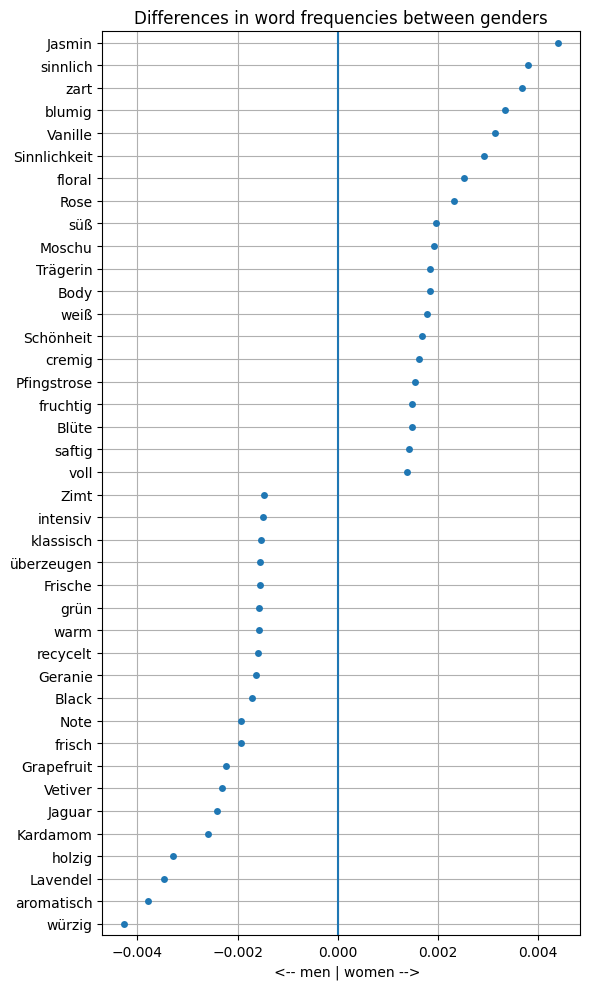

In [22]:
fig, ax = plt.subplots(figsize=(6, 10))
sns.swarmplot(data = dtm_plot, x = "delta", y = "lemma")
ax.axvline(0)
ax.set_ylabel("")
ax.set_xlabel(" "*3 # for horizontal shift of the label
              + "<-- men | women -->")
ax.set_title("Differences in word frequencies between genders")
plt.grid()
fig.tight_layout()# to avoid clipping of the plot (particularly axes labels)

plt.savefig("plots/word_frequencies_DE.png")
plt.show()